In [118]:
!pip install ultralytics pillow


0: 640x320 1 bottle, 1 dining table, 59.3ms
Speed: 1.3ms preprocess, 59.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 320)
Cropped Object 0: Class ID 39.0, Confidence 0.49 5 414 939 1735 
Cropped Object 1: Class ID 60.0, Confidence 0.29 6 1216 942 2043 
Cropped 2 fully visible objects!


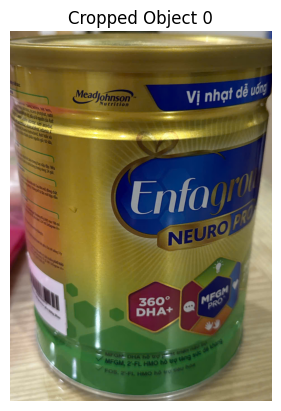

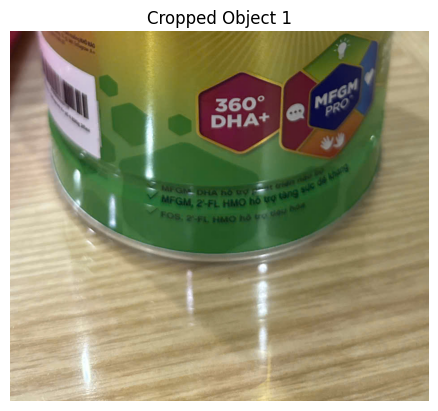

In [130]:
from PIL import Image
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

model = YOLO("yolo11n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger

def detect_and_crop_objects(image_path):
    # Load a pretrained YOLOv8 model

    # Load your image
    image = Image.open(image_path)
    width, height = image.size

    # Perform object detection
    results = model.predict(image)

    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)

        # Check if the object is fully visible
        # if x1 > 0 and y1 > 0 and x2 <= width and y2 <= height:
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)
        print(f"Cropped Object {i}: Class ID {cls_id}, Confidence {conf:.2f} {x1} {y1} {x2} {y2} ")

    print(f"Cropped {len(cropped_images)} fully visible objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()


# Example usage
detect_and_crop_objects("img_test_1.jpg")


0: 640x480 2 mouses, 88.8ms
Speed: 2.6ms preprocess, 88.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)
Cropped Object 0: Class ID 64.0, Confidence 0.79 133 197 694 641 
Cropped Object 1: Class ID 64.0, Confidence 0.58 275 715 571 1094 
Cropped 2 fully visible objects!


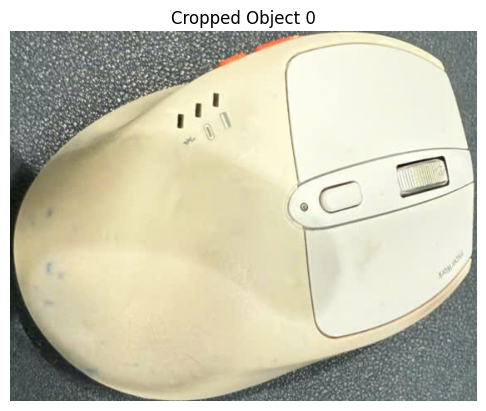

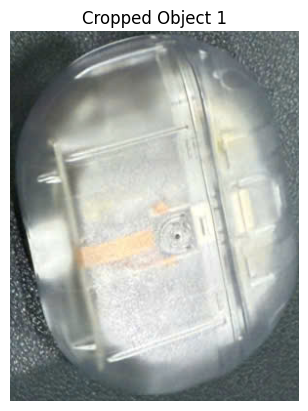

In [131]:
detect_and_crop_objects("img_test_13.jpg")


0: 640x320 2 mouses, 1 keyboard, 1 cell phone, 60.1ms
Speed: 2.2ms preprocess, 60.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 320)
Cropped Object 0: Class ID 64.0, Confidence 0.93 449 261 914 470 
Cropped Object 1: Class ID 66.0, Confidence 0.68 1 101 363 462 
Cropped Object 2: Class ID 64.0, Confidence 0.68 47 1019 903 1576 
Cropped Object 3: Class ID 67.0, Confidence 0.60 48 1021 901 1576 
Cropped 4 fully visible objects!


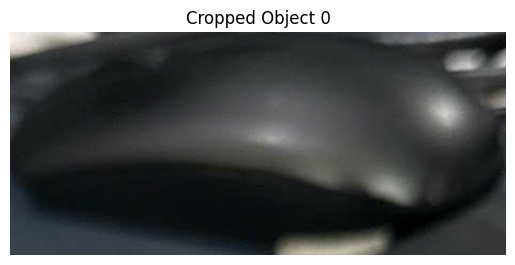

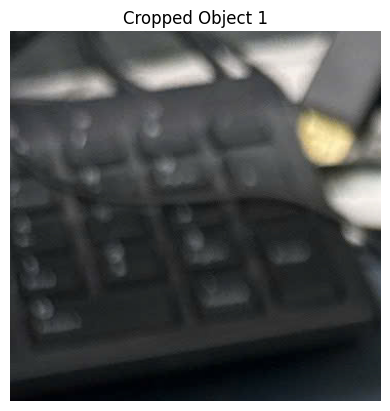

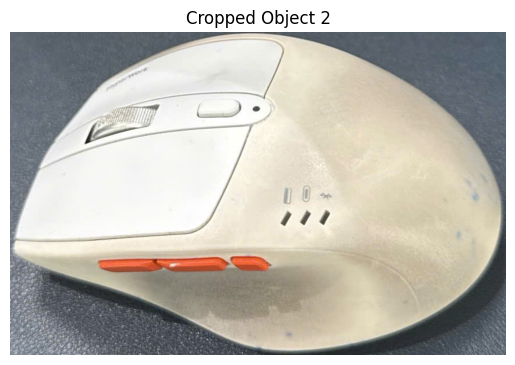

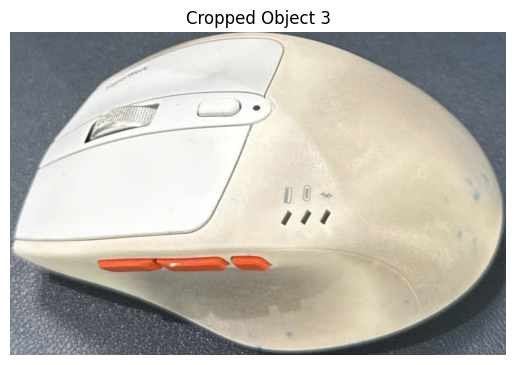

In [132]:
detect_and_crop_objects("img_test_3.jpg")

In [122]:
detect_and_crop_objects("img_test_6.webp")


0: 640x640 1 suitcase, 122.4ms
Speed: 2.1ms preprocess, 122.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Cropped 0 fully visible objects!



0: 480x640 2 tvs, 3 mouses, 2 keyboards, 79.2ms
Speed: 2.0ms preprocess, 79.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Cropped Object 0: Class ID 64.0, Confidence 0.96 899 493 1118 728 
Cropped Object 1: Class ID 66.0, Confidence 0.91 12 258 749 579 
Cropped Object 2: Class ID 64.0, Confidence 0.75 942 249 1180 354 
Cropped Object 4: Class ID 66.0, Confidence 0.62 4 127 856 320 
Cropped Object 5: Class ID 64.0, Confidence 0.40 773 354 926 452 
Cropped 5 fully visible objects!


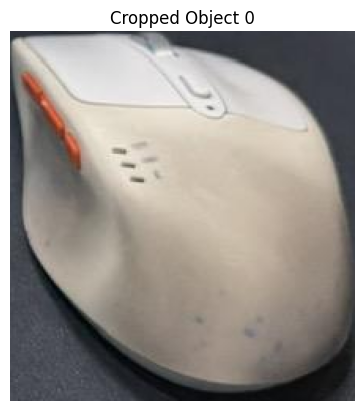

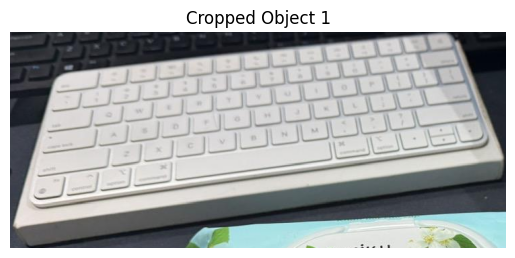

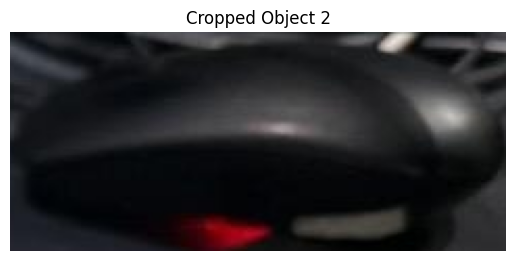

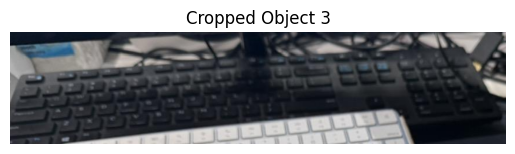

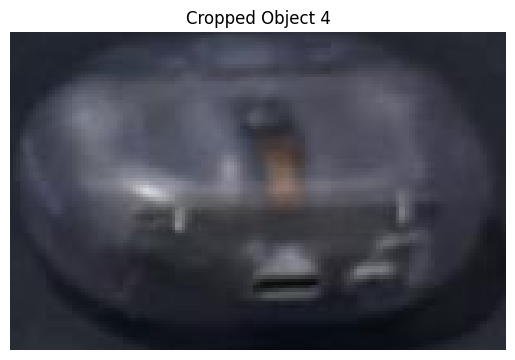

In [123]:
detect_and_crop_objects("img_test_16.jpg")